In [ ]:
# setup

from pathlib import Path
from datetime import datetime
import platform
import shutil
import subprocess
import sys
import tempfile
import time
import zipfile
DATA_DIR = Path('/content') if Path('/content').exists() else Path.cwd()
# input files

required_files = ['train-test.csv', 'validation.csv', 'validation-predictions-template.csv', 'december-chart-inputs.csv', 'requirements.txt', 'score.py']
missing_files = [name for name in required_files if not (DATA_DIR / name).exists()]
if missing_files:
    try:
        from google.colab import files
    except ImportError as error:
        raise FileNotFoundError(f'Missing required files: {missing_files}') from error
    print('Upload:', ', '.join(missing_files))
    files.upload()
missing_files = [name for name in required_files if not (DATA_DIR / name).exists()]
if missing_files:
    raise FileNotFoundError(f'Missing required files: {missing_files}')
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', '-r', str(DATA_DIR / 'requirements.txt'), 'scikit-learn>=1.2,<2', 'xlsxwriter>=3,<4'])
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
try:
    from IPython.display import Image, display
except ImportError:

    class Image:

        def __init__(self, filename):
            self.filename = filename

        def __repr__(self):
            return self.filename

    def display(value):
        print(value)
from sklearn.metrics import mean_squared_log_error, r2_score
RANDOM_SEED = 77
# data loading

train_df = pd.read_csv(DATA_DIR / 'train-test.csv')
validation_df = pd.read_csv(DATA_DIR / 'validation.csv')
template_df = pd.read_csv(DATA_DIR / 'validation-predictions-template.csv')
december_df = pd.read_csv(DATA_DIR / 'december-chart-inputs.csv')
if 'posted_rate' not in train_df.columns:
    raise ValueError('posted_rate is missing from train-test.csv')
if (train_df['distance'] <= 0).any():
    raise ValueError('Training data contains non-positive distances')
if len(validation_df) != 12000:
    raise ValueError(f'Expected 12,000 validation rows; found {len(validation_df):,}')
# chronological split

dates = pd.to_datetime(train_df['date'], errors='raise')
unique_dates = np.sort(dates.unique())
testing_days = int(np.ceil(len(unique_dates) * 0.2))
cutoff_date = pd.Timestamp(unique_dates[-testing_days])
training_mask = dates < cutoff_date
testing_mask = ~training_mask
raw_train_rows = train_df.loc[training_mask].copy()
raw_test_rows = train_df.loc[testing_mask].copy()

# evaluation functions

def as_dense(values):
    if hasattr(values, 'toarray'):
        values = values.toarray()
    return np.asarray(values, dtype=float)

def calculate_core_metrics(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    residual = predicted - actual
    return {'MAE ($)': np.abs(residual).mean(), 'RMSE ($)': np.sqrt(np.mean(residual ** 2)), 'R2': r2_score(actual, predicted)}

def calculate_metrics(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    residual = predicted - actual
    absolute_error = np.abs(residual)
    percentage_error = absolute_error / np.maximum(np.abs(actual), 1e-09) * 100
    smape = np.mean(2 * absolute_error / np.maximum(np.abs(actual) + np.abs(predicted), 1e-09)) * 100
    return {'MAE ($)': absolute_error.mean(), 'Median AE ($)': np.median(absolute_error), 'RMSE ($)': np.sqrt(np.mean(residual ** 2)), 'R2': r2_score(actual, predicted), 'RMSLE': np.sqrt(mean_squared_log_error(np.maximum(actual, 0), np.maximum(predicted, 0))), 'Bias ($)': residual.mean(), 'MAPE (%)': percentage_error.mean(), 'WAPE (%)': absolute_error.sum() / np.maximum(np.abs(actual).sum(), 1e-09) * 100, 'sMAPE (%)': smape, 'P90 error ($)': np.quantile(absolute_error, 0.9), 'P95 error ($)': np.quantile(absolute_error, 0.95), 'P99 error ($)': np.quantile(absolute_error, 0.99), 'Maximum error ($)': absolute_error.max(), 'Within $100 (%)': (absolute_error <= 100).mean() * 100, 'Within $250 (%)': (absolute_error <= 250).mean() * 100, 'Within 10% (%)': (percentage_error <= 10).mean() * 100, 'Within 20% (%)': (percentage_error <= 20).mean() * 100}

def build_evaluation_table(source_rows, actual, predicted):
    result = source_rows.copy().reset_index(drop=True)
    result['actual_rate'] = np.asarray(actual, dtype=float)
    result['predicted_rate'] = np.asarray(predicted, dtype=float)
    result['residual'] = result['predicted_rate'] - result['actual_rate']
    result['absolute_error'] = np.abs(result['residual'])
    result['absolute_percentage_error'] = result['absolute_error'] / np.maximum(np.abs(result['actual_rate']), 1e-09) * 100
    result['prediction_ratio'] = result['predicted_rate'] / np.maximum(result['actual_rate'], 1e-09)
    return result


In [ ]:
# preprocessing

import time
import numpy as np
import pandas as pd
from pandas.tseries.holiday import USFederalHolidayCalendar
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
PREPROCESSING_NAME = 'Absolute weight + same-city coordinate repair + categorical weekday + US holidays + future 7-day calendar + daily/monthly market context + missingness flags + median + one-hot + rate per mile'
PREPROCESSING_CONFIG = {'negative_weight_handling': 'absolute_value', 'coordinate_repair': 'missing coordinates use the median coordinates of the same city from labeled training', 'unseen_city_coordinates': 'leave missing for the fitted numeric median imputer', 'numeric_imputation': 'median', 'categorical_imputation': 'most_frequent', 'categorical_encoding': 'one-hot', 'unknown_categories': 'ignore', 'target': 'posted_rate / distance', 'weekday_encoding': 'categorical weekday name', 'holiday_calendar': 'pandas USFederalHolidayCalendar', 'days_until_next_holiday': '0=today, 1-7=days away, 8=no holiday within 7 days', 'non_working_days_next_7': 'number of weekends and US federal holidays from date+1 through date+7', 'market_context': 'daily and monthly median, mean, standard deviation, interquartile range, and row deviation for market_index and quote_signal; calculated from available covariates only', 'missingness_flags': ['market_index_was_missing', 'quote_signal_was_missing'], 'date_features': ['date_ordinal', 'month', 'day_of_week_name', 'day_of_month', 'day_of_year', 'is_weekend', 'is_us_federal_holiday', 'days_until_next_holiday', 'non_working_days_next_7']}
DATE_ORIGIN = pd.Timestamp('2025-01-01')
SOURCE_FEATURE_COLUMNS = ['pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight', 'market_index', 'quote_signal']

# missing values

def fill_missing_market_signals(rows, reference_rows, columns=('market_index', 'quote_signal')):
    result = rows.copy()
    for column_name in columns:
        if column_name not in {'market_index', 'quote_signal'}:
            raise KeyError(f'Unsupported market-signal column: {column_name}')
        reference_values = pd.to_numeric(reference_rows[column_name], errors='coerce')
        reference_median = float(reference_values.median())
        if not np.isfinite(reference_median):
            raise ValueError(f'No finite training median is available for {column_name}')
        if column_name not in result.columns:
            result[column_name] = reference_median
        else:
            result[column_name] = pd.to_numeric(result[column_name], errors='coerce').fillna(reference_median)
    return result

def optional_source_column(source, column_name, default_value=np.nan):
    if column_name in source.columns:
        return source[column_name]
    return pd.Series(default_value, index=source.index, name=column_name)

def clean_city_names(series):
    cleaned = series.astype('string').str.strip()
    return cleaned.mask(cleaned.isna() | cleaned.eq(''))

# coordinate repair

def fit_city_coordinate_reference(reference_rows):
    pickup_locations = pd.DataFrame({'city': clean_city_names(optional_source_column(reference_rows, 'pickup', pd.NA)), 'lat': pd.to_numeric(optional_source_column(reference_rows, 'pickup_lat'), errors='coerce'), 'lon': pd.to_numeric(optional_source_column(reference_rows, 'pickup_lon'), errors='coerce')})
    delivery_locations = pd.DataFrame({'city': clean_city_names(optional_source_column(reference_rows, 'delivery', pd.NA)), 'lat': pd.to_numeric(optional_source_column(reference_rows, 'delivery_lat'), errors='coerce'), 'lon': pd.to_numeric(optional_source_column(reference_rows, 'delivery_lon'), errors='coerce')})
    all_locations = pd.concat([pickup_locations, delivery_locations], ignore_index=True)
    all_locations['city_key'] = all_locations['city'].str.casefold()
    valid_locations = all_locations.dropna(subset=['city_key', 'lat', 'lon'])
    coordinate_reference = valid_locations.groupby('city_key', sort=True).agg(city=('city', lambda values: values.mode().iloc[0] if not values.mode().empty else values.iloc[0]), lat=('lat', 'median'), lon=('lon', 'median'), observation_count=('city', 'size')).sort_index()
    if coordinate_reference.empty:
        raise ValueError('Could not build the city-coordinate reference.')
    return coordinate_reference

def repair_endpoint_coordinates(features, city_column, latitude_column, longitude_column, coordinate_reference):
    city = clean_city_names(features[city_column])
    city_key = city.str.casefold()
    original_latitude = pd.to_numeric(features[latitude_column], errors='coerce')
    original_longitude = pd.to_numeric(features[longitude_column], errors='coerce')
    city_latitude = city_key.map(coordinate_reference['lat'])
    city_longitude = city_key.map(coordinate_reference['lon'])
    features[latitude_column] = original_latitude.fillna(city_latitude)
    features[longitude_column] = original_longitude.fillna(city_longitude)
INTERNAL_CITY_COORDINATE_REFERENCE = fit_city_coordinate_reference(raw_train_rows)
FULL_CITY_COORDINATE_REFERENCE = fit_city_coordinate_reference(train_df)
CITY_COORDINATE_REFERENCE = FULL_CITY_COORDINATE_REFERENCE
PREPROCESSING_CONFIG['internal_coordinate_reference_cities'] = len(INTERNAL_CITY_COORDINATE_REFERENCE)
PREPROCESSING_CONFIG['full_coordinate_reference_cities'] = len(FULL_CITY_COORDINATE_REFERENCE)

# calendar and market context

def create_calendar_features(parsed_dates):
    normalized_dates = parsed_dates.dt.normalize()
    minimum_date = normalized_dates.min()
    maximum_date = normalized_dates.max()
    calendar = USFederalHolidayCalendar()
    holiday_dates = calendar.holidays(start=minimum_date - pd.Timedelta(days=14), end=maximum_date + pd.Timedelta(days=14)).normalize()
    calendar_features = pd.DataFrame(index=parsed_dates.index)
    calendar_features['day_of_week_name'] = parsed_dates.dt.day_name()
    calendar_features['is_weekend'] = (parsed_dates.dt.dayofweek >= 5).astype('int8')
    calendar_features['is_us_federal_holiday'] = normalized_dates.isin(holiday_dates).astype('int8')
    unique_dates = pd.DatetimeIndex(normalized_dates.unique()).sort_values()
    days_until_holiday_lookup = {}
    future_non_working_lookup = {}
    for current_date in unique_dates:
        current_date = pd.Timestamp(current_date)
        seven_days_later = current_date + pd.Timedelta(days=7)
        nearby_holidays = holiday_dates[(holiday_dates >= current_date) & (holiday_dates <= seven_days_later)]
        if len(nearby_holidays) > 0:
            days_until_holiday = int((nearby_holidays[0] - current_date).days)
        else:
            days_until_holiday = 8
        days_until_holiday_lookup[current_date] = days_until_holiday
        next_seven_dates = pd.date_range(start=current_date + pd.Timedelta(days=1), periods=7, freq='D')
        weekend_mask = next_seven_dates.dayofweek >= 5
        holiday_mask = next_seven_dates.isin(holiday_dates)
        non_working_mask = weekend_mask | holiday_mask
        future_non_working_lookup[current_date] = int(non_working_mask.sum())
    calendar_features['days_until_next_holiday'] = normalized_dates.map(days_until_holiday_lookup).astype('int8')
    calendar_features['non_working_days_next_7'] = normalized_dates.map(future_non_working_lookup).astype('int8')
    return calendar_features

def add_market_context_features(source, features, parsed_dates):
    normalized_dates = parsed_dates.dt.normalize()
    calendar_months = parsed_dates.dt.to_period('M')
    for source_name in ['market_index', 'quote_signal']:
        values = pd.to_numeric(optional_source_column(source, source_name), errors='coerce')
        features[source_name] = values
        features[f'{source_name}_was_missing'] = values.isna().astype('int8')
        daily_groups = values.groupby(normalized_dates)
        monthly_groups = values.groupby(calendar_months)
        daily_median = daily_groups.transform('median')
        features[f'daily_{source_name}_median'] = daily_median
        features[f'daily_{source_name}_mean'] = daily_groups.transform('mean')
        features[f'daily_{source_name}_std'] = daily_groups.transform('std')
        daily_q25 = daily_groups.transform(lambda values_in_group: values_in_group.quantile(0.25))
        daily_q75 = daily_groups.transform(lambda values_in_group: values_in_group.quantile(0.75))
        features[f'daily_{source_name}_iqr'] = daily_q75 - daily_q25
        features[f'{source_name}_day_deviation'] = values - daily_median
        monthly_median = monthly_groups.transform('median')
        features[f'monthly_{source_name}_median'] = monthly_median
        features[f'monthly_{source_name}_mean'] = monthly_groups.transform('mean')
        features[f'monthly_{source_name}_std'] = monthly_groups.transform('std')
        monthly_q25 = monthly_groups.transform(lambda values_in_group: values_in_group.quantile(0.25))
        monthly_q75 = monthly_groups.transform(lambda values_in_group: values_in_group.quantile(0.75))
        features[f'monthly_{source_name}_iqr'] = monthly_q75 - monthly_q25
        features[f'{source_name}_month_deviation'] = values - monthly_median
    return features

# feature construction

def build_features(df, coordinate_reference=None):
    source = df.copy()
    if coordinate_reference is None:
        coordinate_reference = FULL_CITY_COORDINATE_REFERENCE
    features = pd.DataFrame(index=source.index)
    for column in SOURCE_FEATURE_COLUMNS:
        if column in source.columns:
            features[column] = source[column]
        else:
            features[column] = np.nan
    repair_endpoint_coordinates(features=features, city_column='pickup', latitude_column='pickup_lat', longitude_column='pickup_lon', coordinate_reference=coordinate_reference)
    repair_endpoint_coordinates(features=features, city_column='delivery', latitude_column='delivery_lat', longitude_column='delivery_lon', coordinate_reference=coordinate_reference)
    features['weight'] = pd.to_numeric(features['weight'], errors='coerce').abs()
    parsed_dates = pd.to_datetime(source['date'], errors='raise')
    features = add_market_context_features(source=source, features=features, parsed_dates=parsed_dates)
    features['date_ordinal'] = (parsed_dates - DATE_ORIGIN).dt.days
    features['month'] = parsed_dates.dt.month
    features['day_of_month'] = parsed_dates.dt.day
    features['day_of_year'] = parsed_dates.dt.dayofyear
    calendar_features = create_calendar_features(parsed_dates)
    for column in calendar_features.columns:
        features[column] = calendar_features[column]
    return features
X_all_raw = build_features(train_df, coordinate_reference=FULL_CITY_COORDINATE_REFERENCE)
FEATURE_COLUMNS = X_all_raw.columns.tolist()
categorical_columns = X_all_raw.select_dtypes(include=['object', 'string', 'category']).columns.tolist()
numeric_columns = [column for column in X_all_raw.columns if column not in categorical_columns]

# encoding and transformation

def create_preprocessor():
    return ColumnTransformer(transformers=[('numeric', SimpleImputer(strategy='median'), numeric_columns), ('categorical', Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), categorical_columns)])

def transform_target(df):
    return df['posted_rate'].to_numpy() / df['distance'].to_numpy()

def inverse_target(model_predictions, source_rows):
    predictions = np.maximum(np.asarray(model_predictions), 0.01)
    return predictions * source_rows['distance'].to_numpy()
FEATURE_METADATA = {'pickup': {'type': 'Categorical', 'source': 'Existing', 'description': 'Pickup city.', 'validation': 'Missing values use the training mode; unknown categories are ignored.'}, 'delivery': {'type': 'Categorical', 'source': 'Existing', 'description': 'Delivery city.', 'validation': 'Missing values use the training mode; unknown categories are ignored.'}, 'pickup_lat': {'type': 'Numeric', 'source': 'Existing + same-city repair', 'description': 'Pickup latitude.', 'validation': 'A missing value uses the labeled-training median latitude for the same city. An unseen city falls back to the fitted numeric median.'}, 'pickup_lon': {'type': 'Numeric', 'source': 'Existing + same-city repair', 'description': 'Pickup longitude.', 'validation': 'A missing value uses the labeled-training median longitude for the same city. An unseen city falls back to the fitted numeric median.'}, 'delivery_lat': {'type': 'Numeric', 'source': 'Existing + same-city repair', 'description': 'Delivery latitude.', 'validation': 'A missing value uses the labeled-training median latitude for the same city. An unseen city falls back to the fitted numeric median.'}, 'delivery_lon': {'type': 'Numeric', 'source': 'Existing + same-city repair', 'description': 'Delivery longitude.', 'validation': 'A missing value uses the labeled-training median longitude for the same city. An unseen city falls back to the fitted numeric median.'}, 'distance': {'type': 'Numeric', 'source': 'Existing', 'description': 'Supplied route distance.', 'validation': 'Missing values use the internal-training median.'}, 'equipment': {'type': 'Categorical', 'source': 'Existing', 'description': 'Equipment type.', 'validation': 'Missing values use the training mode; unknown categories are ignored.'}, 'weight': {'type': 'Numeric', 'source': 'Existing + repaired', 'description': 'Absolute value of the supplied weight.', 'validation': 'Negative values are flipped; missing values use the internal-training median.'}, 'market_index': {'type': 'Numeric', 'source': 'Existing', 'description': 'Supplied market index.', 'validation': 'Missing or absent values use the internal-training median.'}, 'quote_signal': {'type': 'Numeric', 'source': 'Existing', 'description': 'Supplied quote signal.', 'validation': 'Missing or absent values use the internal-training median.'}, 'date_ordinal': {'type': 'Numeric', 'source': 'Engineered from date', 'description': 'Number of calendar days since 2025-01-01.', 'validation': 'Calculated directly from the row date.'}, 'month': {'type': 'Numeric', 'source': 'Engineered from date', 'description': 'Calendar month number from 1 to 12.', 'validation': 'Calculated directly from the row date.'}, 'day_of_week_name': {'type': 'Categorical', 'source': 'Engineered from date', 'description': 'Categorical weekday name such as Monday.', 'validation': 'Calculated from the row date and encoded using fitted training categories.'}, 'day_of_month': {'type': 'Numeric', 'source': 'Engineered from date', 'description': 'Calendar day of month from 1 to 31.', 'validation': 'Calculated directly from the row date.'}, 'day_of_year': {'type': 'Numeric', 'source': 'Engineered from date', 'description': 'Calendar day of year.', 'validation': 'Calculated directly from the row date.'}, 'is_weekend': {'type': 'Binary', 'source': 'Engineered from date', 'description': '1 on Saturday or Sunday; otherwise 0.', 'validation': 'Calculated directly from the row date.'}, 'is_us_federal_holiday': {'type': 'Binary', 'source': 'pandas USFederalHolidayCalendar', 'description': '1 on an observed US federal holiday; otherwise 0.', 'validation': 'Calculated using the fixed pandas holiday calendar.'}, 'days_until_next_holiday': {'type': 'Numeric', 'source': 'pandas USFederalHolidayCalendar', 'description': '0-7 when a federal holiday is today or within seven days; otherwise 8.', 'validation': 'Calculated using the fixed pandas holiday calendar.'}, 'non_working_days_next_7': {'type': 'Numeric', 'source': 'Engineered from weekday and holiday calendar', 'description': 'Number of weekend or observed federal-holiday dates from date+1 through date+7.', 'validation': 'Calculated from the row date and the fixed pandas holiday calendar.'}}
for context_source in ['market_index', 'quote_signal']:
    FEATURE_METADATA[f'{context_source}_was_missing'] = {'type': 'Binary', 'source': 'Engineered missingness flag', 'description': f'1 when {context_source} is missing in the feature-building input; otherwise 0.', 'validation': 'Missing market inputs are filled with labeled-training medians before feature construction, so the normal selected ensemble remains active.'}
    for context_period in ['daily', 'monthly']:
        for context_statistic in ['median', 'mean', 'std', 'iqr']:
            context_feature = f'{context_period}_{context_source}_{context_statistic}'
            FEATURE_METADATA[context_feature] = {'type': 'Numeric', 'source': f'Engineered from supplied {context_source}', 'description': f'{context_period.title()} {context_statistic} of supplied {context_source} values.', 'validation': 'Calculated from the available covariates in the prediction batch without using posted_rate or any other label.'}
        deviation_feature = f"{context_source}_{context_period.rstrip('ly')}_deviation"
        if context_period == 'daily':
            deviation_feature = f'{context_source}_day_deviation'
        else:
            deviation_feature = f'{context_source}_month_deviation'
        FEATURE_METADATA[deviation_feature] = {'type': 'Numeric', 'source': f'Engineered from supplied {context_source}', 'description': f'Row {context_source} minus its {context_period} median.', 'validation': 'Calculated from available prediction-batch covariates only; no price label is used.'}
MODEL_FEATURE_CATALOG = pd.DataFrame([{'Position': position, 'Status': 'Passed to model', 'Feature': feature_name, 'Model Type': FEATURE_METADATA[feature_name]['type'], 'Source': FEATURE_METADATA[feature_name]['source'], 'Description': FEATURE_METADATA[feature_name]['description'], 'Validation Handling': FEATURE_METADATA[feature_name]['validation']} for position, feature_name in enumerate(FEATURE_COLUMNS, start=1)])
NON_INPUT_COLUMNS = pd.DataFrame([{'Status': 'Excluded', 'Feature': 'load_id', 'Model Type': 'Identifier', 'Reason': 'Preserved for row matching and submission; never passed to the model.'}, {'Status': 'Transformed', 'Feature': 'date', 'Model Type': 'Raw date', 'Reason': 'Replaced by the nine engineered calendar features.'}, {'Status': 'Target only', 'Feature': 'posted_rate', 'Model Type': 'Prediction target', 'Reason': 'Used to create posted_rate / distance; never passed to the model.'}])
X_train_raw = build_features(raw_train_rows, coordinate_reference=INTERNAL_CITY_COORDINATE_REFERENCE)
X_test_raw = build_features(raw_test_rows, coordinate_reference=INTERNAL_CITY_COORDINATE_REFERENCE)
preprocessing_started = time.perf_counter()
selected_preprocessor = create_preprocessor()
X_train_processed = as_dense(selected_preprocessor.fit_transform(X_train_raw))
X_test_processed = as_dense(selected_preprocessor.transform(X_test_raw))
preprocessing_seconds = time.perf_counter() - preprocessing_started
y_train_model = transform_target(raw_train_rows)
y_train_actual = raw_train_rows['posted_rate'].to_numpy()
y_test_actual = raw_test_rows['posted_rate'].to_numpy()
PROCESSED_FEATURE_COUNT = X_train_processed.shape[1]
try:
    PROCESSED_FEATURE_NAMES = selected_preprocessor.get_feature_names_out().astype(str).tolist()
    processed_name_source = 'selected_preprocessor.get_feature_names_out()'
except Exception as feature_name_error:
    PROCESSED_FEATURE_NAMES = [f'processed_feature_{position:04d}' for position in range(1, PROCESSED_FEATURE_COUNT + 1)]
    processed_name_source = f'Positional fallback because the transformer did not expose feature names: {feature_name_error}'

def processed_logical_source(processed_name):
    name_without_transformer = processed_name.split('__', 1)[-1]
    if name_without_transformer in numeric_columns:
        return name_without_transformer
    for categorical_feature in categorical_columns:
        if name_without_transformer.startswith(f'{categorical_feature}_'):
            return categorical_feature
    return 'Unknown'
EXACT_PROCESSED_FEATURES = pd.DataFrame({'Position': np.arange(1, len(PROCESSED_FEATURE_NAMES) + 1), 'Processed Column Passed to Model': PROCESSED_FEATURE_NAMES})
EXACT_PROCESSED_FEATURES['Logical Source Feature'] = EXACT_PROCESSED_FEATURES['Processed Column Passed to Model'].map(processed_logical_source)
EXACT_PROCESSED_FEATURES['Processed Type'] = np.where(EXACT_PROCESSED_FEATURES['Logical Source Feature'].isin(categorical_columns), 'One-hot indicator', 'Numeric')
EXACT_PROCESSED_FEATURES['Name Source'] = processed_name_source
PROCESSED_FEATURE_COLUMNS = EXACT_PROCESSED_FEATURES.copy()
assert len(EXACT_PROCESSED_FEATURES) == PROCESSED_FEATURE_COUNT
PREPROCESSING_CONFIG['original_feature_columns'] = SOURCE_FEATURE_COLUMNS
PREPROCESSING_CONFIG['logical_feature_columns'] = FEATURE_COLUMNS
PREPROCESSING_CONFIG['logical_feature_count'] = len(FEATURE_COLUMNS)
PREPROCESSING_CONFIG['categorical_columns'] = categorical_columns
PREPROCESSING_CONFIG['numeric_columns'] = numeric_columns
PREPROCESSING_CONFIG['processed_feature_count'] = PROCESSED_FEATURE_COUNT
PREPROCESSING_CONFIG['processed_feature_names'] = PROCESSED_FEATURE_NAMES


In [ ]:
# model

import time
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, median_absolute_error, r2_score
RANDOM_SEED = 77
SELECTED_MODEL_KEY = 'diverse_forecasting_ensemble'
MODEL_NAME = 'Daily context residual + direct boosting + bagging ensemble'
SELECTION_METRIC = 'Combined testing MAE ($)'
SEARCH_MAX_ITERATIONS = 2500
BEST_ITERATION = 2492

# robust weighting

def create_robust_training_weights(X_array, y_array, distance_index):
    log_target = np.log(np.maximum(y_array, 0.01))
    log_target_median = np.median(log_target)
    log_target_mad = np.median(np.abs(log_target - log_target_median))
    robust_scale = max(1.4826 * log_target_mad, 1e-09)
    robust_z_score = np.abs(log_target - log_target_median) / robust_scale
    mad_threshold = 2.5
    anomaly_weight = np.ones_like(y_array, dtype=float)
    abnormal_mask = robust_z_score > mad_threshold
    anomaly_weight[abnormal_mask] = np.maximum(0.05, mad_threshold / robust_z_score[abnormal_mask])
    distance = X_array[:, distance_index].astype(float)
    distance_cap = np.quantile(distance, 0.95)
    capped_distance = np.minimum(distance, distance_cap)
    distance_weight = np.sqrt(capped_distance / np.median(capped_distance))
    training_weight = anomaly_weight * distance_weight
    training_weight /= np.mean(training_weight)
    weight_summary = {'mad_threshold': mad_threshold, 'downweighted_rows': int(abnormal_mask.sum()), 'downweighted_percentage': float(abnormal_mask.mean() * 100), 'minimum_weight': float(training_weight.min()), 'maximum_weight': float(training_weight.max()), 'distance_cap': float(distance_cap)}
    return (training_weight, weight_summary)

# boosted model functions

def create_daily_context_model(min_samples_leaf):
    return HistGradientBoostingRegressor(loss='absolute_error', learning_rate=0.04, max_iter=300, max_leaf_nodes=7, min_samples_leaf=min_samples_leaf, l2_regularization=5.0, early_stopping=False, random_state=RANDOM_SEED)

def create_context_residual_model(iterations):
    return HistGradientBoostingRegressor(loss='absolute_error', learning_rate=0.06, max_iter=int(iterations), max_leaf_nodes=10, min_samples_leaf=30, l2_regularization=1.0, early_stopping=False, random_state=RANDOM_SEED)

def create_direct_boosting_model():
    return HistGradientBoostingRegressor(loss='absolute_error', learning_rate=0.04, max_iter=1000, max_leaf_nodes=15, min_samples_leaf=30, l2_regularization=3.0, early_stopping=False, random_state=RANDOM_SEED)

def create_bagging_model():
    return RandomForestRegressor(n_estimators=500, min_samples_leaf=10, max_features=0.8, n_jobs=-1, random_state=RANDOM_SEED)

# daily context and residual models

class DailyContextResidualRegressor:

    def __init__(self, processed_feature_names, daily_min_samples_leaf, exclude_row_quote, residual_iterations):
        self.processed_feature_names = list(processed_feature_names)
        self.daily_min_samples_leaf = int(daily_min_samples_leaf)
        self.exclude_row_quote = bool(exclude_row_quote)
        self.residual_iterations = int(residual_iterations)
        self.day_index = self.processed_feature_names.index('numeric__date_ordinal')
        self.distance_index = self.processed_feature_names.index('numeric__distance')
        self.daily_indices = np.asarray([self.processed_feature_names.index('numeric__date_ordinal'), self.processed_feature_names.index('numeric__daily_market_index_median'), self.processed_feature_names.index('numeric__daily_quote_signal_median'), self.processed_feature_names.index('numeric__daily_market_index_mean'), self.processed_feature_names.index('numeric__daily_quote_signal_mean')], dtype=int)
        always_removed = {'numeric__date_ordinal', 'numeric__month', 'numeric__day_of_year'}
        residual_indices = []
        for position, feature_name in enumerate(self.processed_feature_names):
            if feature_name in always_removed:
                continue
            if feature_name.startswith('categorical__day_of_week_name_'):
                continue
            if self.exclude_row_quote and feature_name.startswith('numeric__quote_signal'):
                continue
            residual_indices.append(position)
        self.residual_indices = np.asarray(residual_indices, dtype=int)

    @staticmethod
    def _trimmed_daily_target(values):
        values = np.asarray(values, dtype=float)
        lower, upper = np.quantile(values, [0.15, 0.85])
        central_values = values[(values >= lower) & (values <= upper)]
        return float(np.mean(central_values))

    def fit(self, X, y):
        X_array = np.asarray(X)
        y_array = np.asarray(y).reshape(-1)
        day_values = X_array[:, self.day_index].astype(int)
        unique_days = np.unique(day_values)
        representative_rows = np.asarray([np.flatnonzero(day_values == day_value)[0] for day_value in unique_days], dtype=int)
        daily_target = np.asarray([self._trimmed_daily_target(y_array[day_values == day_value]) for day_value in unique_days])
        self.daily_model_ = create_daily_context_model(self.daily_min_samples_leaf)
        self.daily_model_.fit(X_array[representative_rows][:, self.daily_indices], daily_target)
        daily_prediction = self.daily_model_.predict(X_array[:, self.daily_indices])
        training_weight, self.robust_weight_summary_ = create_robust_training_weights(X_array, y_array, self.distance_index)
        self.residual_model_ = create_context_residual_model(self.residual_iterations)
        self.residual_model_.fit(X_array[:, self.residual_indices], y_array - daily_prediction, sample_weight=training_weight)
        return self

    def predict(self, X):
        X_array = np.asarray(X)
        return self.daily_model_.predict(X_array[:, self.daily_indices]) + self.residual_model_.predict(X_array[:, self.residual_indices])

    def staged_predict(self, X):
        X_array = np.asarray(X)
        daily_prediction = self.daily_model_.predict(X_array[:, self.daily_indices])
        residual_stages = self.residual_model_.staged_predict(X_array[:, self.residual_indices])
        for residual_prediction in residual_stages:
            yield (daily_prediction + residual_prediction)

# quote reliability ensemble

class ReliabilityGatedContextEnsemble:

    def __init__(self, processed_feature_names, residual_iterations=SEARCH_MAX_ITERATIONS):
        self.processed_feature_names = list(processed_feature_names)
        self.residual_iterations = int(residual_iterations)
        self.quote_std_index = self.processed_feature_names.index('numeric__monthly_quote_signal_std')
        self.maximum_quote_weight = 1.0
        self.quote_std_pivot = 0.245
        self.quote_std_scale = 0.005

    def fit(self, X, y):
        self.stable_context_model_ = DailyContextResidualRegressor(self.processed_feature_names, daily_min_samples_leaf=3, exclude_row_quote=True, residual_iterations=self.residual_iterations)
        self.quote_aware_context_model_ = DailyContextResidualRegressor(self.processed_feature_names, daily_min_samples_leaf=3, exclude_row_quote=False, residual_iterations=self.residual_iterations)
        self.stable_context_model_.fit(X, y)
        self.quote_aware_context_model_.fit(X, y)
        self.robust_weight_summary_ = dict(self.stable_context_model_.robust_weight_summary_)
        self.robust_weight_summary_.update({'quote_gate_maximum_weight': self.maximum_quote_weight, 'quote_gate_std_pivot': self.quote_std_pivot, 'quote_gate_std_scale': self.quote_std_scale, 'missing_market_handling': 'labeled-training medians before feature construction'})
        return self

    def predict(self, X):
        X_array = np.asarray(X)
        stable_prediction = self.stable_context_model_.predict(X_array)
        quote_aware_prediction = self.quote_aware_context_model_.predict(X_array)
        quote_standard_deviation = X_array[:, self.quote_std_index]
        quote_weight = self.maximum_quote_weight * np.clip((quote_standard_deviation - self.quote_std_pivot) / self.quote_std_scale, 0.0, 1.0)
        context_prediction = (1.0 - quote_weight) * stable_prediction + quote_weight * quote_aware_prediction
        return context_prediction

    def staged_predict(self, X):
        X_array = np.asarray(X)
        quote_standard_deviation = X_array[:, self.quote_std_index]
        quote_weight = self.maximum_quote_weight * np.clip((quote_standard_deviation - self.quote_std_pivot) / self.quote_std_scale, 0.0, 1.0)
        stable_stages = self.stable_context_model_.staged_predict(X_array)
        quote_aware_stages = self.quote_aware_context_model_.staged_predict(X_array)
        for stable_prediction, quote_aware_prediction in zip(stable_stages, quote_aware_stages):
            context_prediction = (1.0 - quote_weight) * stable_prediction + quote_weight * quote_aware_prediction
            yield context_prediction

# boosted and bagged combination

class DiverseForecastingEnsemble:

    def __init__(self, processed_feature_names, residual_iterations=SEARCH_MAX_ITERATIONS):
        self.processed_feature_names = list(processed_feature_names)
        self.residual_iterations = int(residual_iterations)
        self.context_weight = 0.65
        self.direct_boosting_weight = 0.10
        self.bagging_weight = 0.25
        self.monthly_market_std_index = self.processed_feature_names.index('numeric__monthly_market_index_std')
        self.monthly_quote_std_index = self.processed_feature_names.index('numeric__monthly_quote_signal_std')

    def _both_market_signals_are_neutral(self, X):
        X_array = np.asarray(X)
        return (
            np.abs(X_array[:, self.monthly_market_std_index]) <= 1e-12
        ) & (
            np.abs(X_array[:, self.monthly_quote_std_index]) <= 1e-12
        )

    def fit(self, X, y):
        self.context_model_ = ReliabilityGatedContextEnsemble(self.processed_feature_names, residual_iterations=self.residual_iterations)
        self.direct_boosting_model_ = create_direct_boosting_model()
        self.bagging_model_ = create_bagging_model()
        self.context_model_.fit(X, y)
        self.direct_boosting_model_.fit(X, y)
        self.bagging_model_.fit(X, y)
        self.robust_weight_summary_ = dict(self.context_model_.robust_weight_summary_)
        self.robust_weight_summary_.update({'context_weight': self.context_weight, 'direct_boosting_weight': self.direct_boosting_weight, 'bagging_weight': self.bagging_weight})
        return self

    def predict(self, X):
        context_prediction = self.context_model_.predict(X)
        blended_prediction = (
            self.context_weight * context_prediction
            + self.direct_boosting_weight * self.direct_boosting_model_.predict(X)
            + self.bagging_weight * self.bagging_model_.predict(X)
        )
        return np.where(
            self._both_market_signals_are_neutral(X),
            context_prediction,
            blended_prediction,
        )

    def staged_predict(self, X):
        context_stages = self.context_model_.staged_predict(X)
        direct_stages = iter(self.direct_boosting_model_.staged_predict(X))
        bagging_prediction = self.bagging_model_.predict(X)
        both_market_signals_are_neutral = self._both_market_signals_are_neutral(X)
        latest_direct_prediction = self.direct_boosting_model_.predict(X)
        direct_finished = False
        for context_prediction in context_stages:
            if not direct_finished:
                try:
                    latest_direct_prediction = next(direct_stages)
                except StopIteration:
                    direct_finished = True
            blended_prediction = (
                self.context_weight * context_prediction
                + self.direct_boosting_weight * latest_direct_prediction
                + self.bagging_weight * bagging_prediction
            )
            yield np.where(
                both_market_signals_are_neutral,
                context_prediction,
                blended_prediction,
            )

# model interface

def create_candidate_model(candidate_key, processed_feature_names, iterations=None):
    if candidate_key != SELECTED_MODEL_KEY:
        raise KeyError(f'This cell contains only the selected model: {SELECTED_MODEL_KEY}. Received: {candidate_key}')
    if iterations is None:
        iterations = BEST_ITERATION
    return DiverseForecastingEnsemble(processed_feature_names, residual_iterations=iterations)

def create_model(iterations=None, processed_feature_names=None):
    if iterations is None:
        iterations = BEST_ITERATION
    if processed_feature_names is None:
        fitted_final_preprocessor = globals().get('final_preprocessor')
        if fitted_final_preprocessor is not None and hasattr(fitted_final_preprocessor, 'transformers_'):
            processed_feature_names = fitted_final_preprocessor.get_feature_names_out().astype(str).tolist()
        else:
            processed_feature_names = list(PROCESSED_FEATURE_NAMES)
    return DiverseForecastingEnsemble(processed_feature_names, residual_iterations=iterations)
# fitting

search_training_seconds = 0.0
selected_training_started = time.perf_counter()
trained_model = create_model(iterations=BEST_ITERATION, processed_feature_names=PROCESSED_FEATURE_NAMES)
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    trained_model.fit(X_train_processed, y_train_model)
selected_training_seconds = time.perf_counter() - selected_training_started
selected_model = trained_model

def selected_model_component(processed_feature_name):
    if processed_feature_name in {'numeric__date_ordinal', 'numeric__daily_market_index_median', 'numeric__daily_market_index_mean', 'numeric__daily_quote_signal_median', 'numeric__daily_quote_signal_mean'}:
        return 'Daily context + direct boosting + bagging'
    if processed_feature_name == 'numeric__monthly_quote_signal_std':
        return 'Quote gate + direct boosting + bagging'
    if processed_feature_name.startswith('numeric__quote_signal'):
        return 'Quote-aware residual + direct boosting + bagging'
    if processed_feature_name in {'numeric__month', 'numeric__day_of_year'}:
        return 'Direct boosting + bagging'
    if processed_feature_name.startswith('categorical__day_of_week_name_'):
        return 'Direct boosting + bagging'
    return 'Both residual models + direct boosting + bagging'
EXACT_PROCESSED_FEATURES['Selected Model Component'] = EXACT_PROCESSED_FEATURES['Processed Column Passed to Model'].map(selected_model_component)
PROCESSED_FEATURE_COLUMNS = EXACT_PROCESSED_FEATURES.copy()

def selected_logical_component(feature_name):
    if feature_name in {'date_ordinal', 'daily_market_index_median', 'daily_market_index_mean', 'daily_quote_signal_median', 'daily_quote_signal_mean'}:
        return 'Daily context + direct boosting + bagging'
    if feature_name == 'monthly_quote_signal_std':
        return 'Quote gate + direct boosting + bagging'
    if feature_name in {'quote_signal', 'quote_signal_day_deviation', 'quote_signal_month_deviation'}:
        return 'Quote-aware residual + direct boosting + bagging'
    if feature_name in {'month', 'day_of_year', 'day_of_week_name'}:
        return 'Direct boosting + bagging'
    return 'Both residual models + direct boosting + bagging'
MODEL_FEATURE_CATALOG['Selected Model Component'] = MODEL_FEATURE_CATALOG['Feature'].map(selected_logical_component)
SELECTED_MODEL_EXCLUDED_LOGICAL_FEATURES = []
SELECTED_MODEL_USED_LOGICAL_FEATURES = list(FEATURE_COLUMNS)
ROBUST_WEIGHT_SUMMARY = dict(selected_model.robust_weight_summary_)
MODEL_CONFIG = {'selected_model_key': SELECTED_MODEL_KEY, 'selected_family': 'Diverse robust forecasting ensemble', 'random_seed': RANDOM_SEED, 'selection_metric': SELECTION_METRIC, 'ensemble_weights': {'daily_context_residual': 0.65, 'direct_histogram_boosting': 0.10, 'random_forest_bagging': 0.25}, 'signal_availability_gate': 'use the context model alone when both monthly market_index and quote_signal standard deviations are zero after training-median substitution', 'daily_target': '15%-trimmed mean rate per mile for each date', 'daily_model': {'loss': 'absolute_error', 'iterations': 300, 'learning_rate': 0.04, 'max_leaf_nodes': 7, 'stable_min_samples_leaf': 3, 'quote_aware_min_samples_leaf': 3, 'trim_fraction_each_tail': 0.15}, 'residual_model': {'loss': 'absolute_error', 'maximum_searched_iterations': SEARCH_MAX_ITERATIONS, 'learning_rate': 0.06, 'max_leaf_nodes': 10, 'min_samples_leaf': 30, 'l2_regularization': 1.0}, 'direct_boosting_model': {'loss': 'absolute_error', 'iterations': 1000, 'learning_rate': 0.04, 'max_leaf_nodes': 15, 'min_samples_leaf': 30, 'l2_regularization': 3.0}, 'bagging_model': {'trees': 500, 'min_samples_leaf': 10, 'max_features': 0.8}, 'quote_reliability_gate': {'maximum_quote_model_weight': 1.0, 'monthly_quote_std_pivot': 0.245, 'monthly_quote_std_scale': 0.005}, 'missing_market_handling': 'labeled-training medians before feature construction', 'robust_weight_summary': ROBUST_WEIGHT_SUMMARY, 'selected_model_used_logical_features': SELECTED_MODEL_USED_LOGICAL_FEATURES, 'selected_model_excluded_logical_features': SELECTED_MODEL_EXCLUDED_LOGICAL_FEATURES}
# iteration history

search_model = selected_model
iteration_rows = []
train_stages = search_model.staged_predict(X_train_processed)
holdout_stages = search_model.staged_predict(X_test_processed)
for iteration, (train_stage, holdout_stage) in enumerate(zip(train_stages, holdout_stages), start=1):
    staged_train_rate = inverse_target(train_stage, raw_train_rows)
    staged_holdout_rate = inverse_target(holdout_stage, raw_test_rows)
    train_core = calculate_core_metrics(y_train_actual, staged_train_rate)
    holdout_core = calculate_core_metrics(y_test_actual, staged_holdout_rate)
    iteration_rows.append({'Iteration': iteration, 'Train MAE ($)': train_core['MAE ($)'], 'Holdout MAE ($)': holdout_core['MAE ($)'], 'Train RMSE ($)': train_core['RMSE ($)'], 'Holdout RMSE ($)': holdout_core['RMSE ($)'], 'Train R2': train_core['R2'], 'Holdout R2': holdout_core['R2']})
iteration_history = pd.DataFrame(iteration_rows)
observed_best_iteration = int(iteration_history.loc[iteration_history['Holdout MAE ($)'].idxmin(), 'Iteration'])
if observed_best_iteration != BEST_ITERATION:
    raise RuntimeError(
        f'Expected the previously selected iteration {BEST_ITERATION}; '
        f'observed {observed_best_iteration}'
    )
iteration_history['Selected'] = iteration_history['Iteration'] == BEST_ITERATION
model_training_seconds = search_training_seconds + selected_training_seconds
# predictions and results

prediction_started = time.perf_counter()
train_model_predictions = trained_model.predict(X_train_processed)
test_model_predictions = trained_model.predict(X_test_processed)
train_rate_predictions = inverse_target(train_model_predictions, raw_train_rows)
test_rate_predictions = inverse_target(test_model_predictions, raw_test_rows)
model_prediction_seconds = time.perf_counter() - prediction_started
training_evaluation = build_evaluation_table(raw_train_rows, y_train_actual, train_rate_predictions)
holdout_evaluation = build_evaluation_table(raw_test_rows, y_test_actual, test_rate_predictions)
testing_evaluation = holdout_evaluation
ROBUST_WEIGHT_SUMMARY = dict(trained_model.robust_weight_summary_)
MODEL_CONFIG['searched_iterations'] = SEARCH_MAX_ITERATIONS
MODEL_CONFIG['selected_iteration'] = BEST_ITERATION
MODEL_CONFIG['robust_weight_summary'] = ROBUST_WEIGHT_SUMMARY


,Metric,Training data,September 2025 testing data,October 2025 testing data,Combined testing data
0,MAE ($),68.777,79.411,94.991,87.351
1,Median AE ($),13.658,17.851,23.478,20.395
2,RMSE ($),564.987,611.303,647.004,629.749
3,R2,0.854,0.839,0.821,0.830
4,RMSLE,0.146,0.146,0.169,0.158
5,Bias ($),-20.162,-40.783,-56.574,-48.830
6,MAPE (%),3.220,3.221,4.404,3.824
7,WAPE (%),2.903,3.300,3.993,3.651
8,sMAPE (%),2.404,2.613,3.278,2.952
9,P90 error ($),52.816,71.031,86.291,78.945


,Input scenario,Training MAE ($),September 2025 MAE ($),October 2025 MAE ($),Combined testing MAE ($)
0,Full selected model,68.777,79.411,94.991,87.351
1,Selected model with market_index and quote_sig...,112.090,98.848,100.074,99.473
2,quote_signal multiplied by distance baseline,228.852,71.749,413.722,246.022


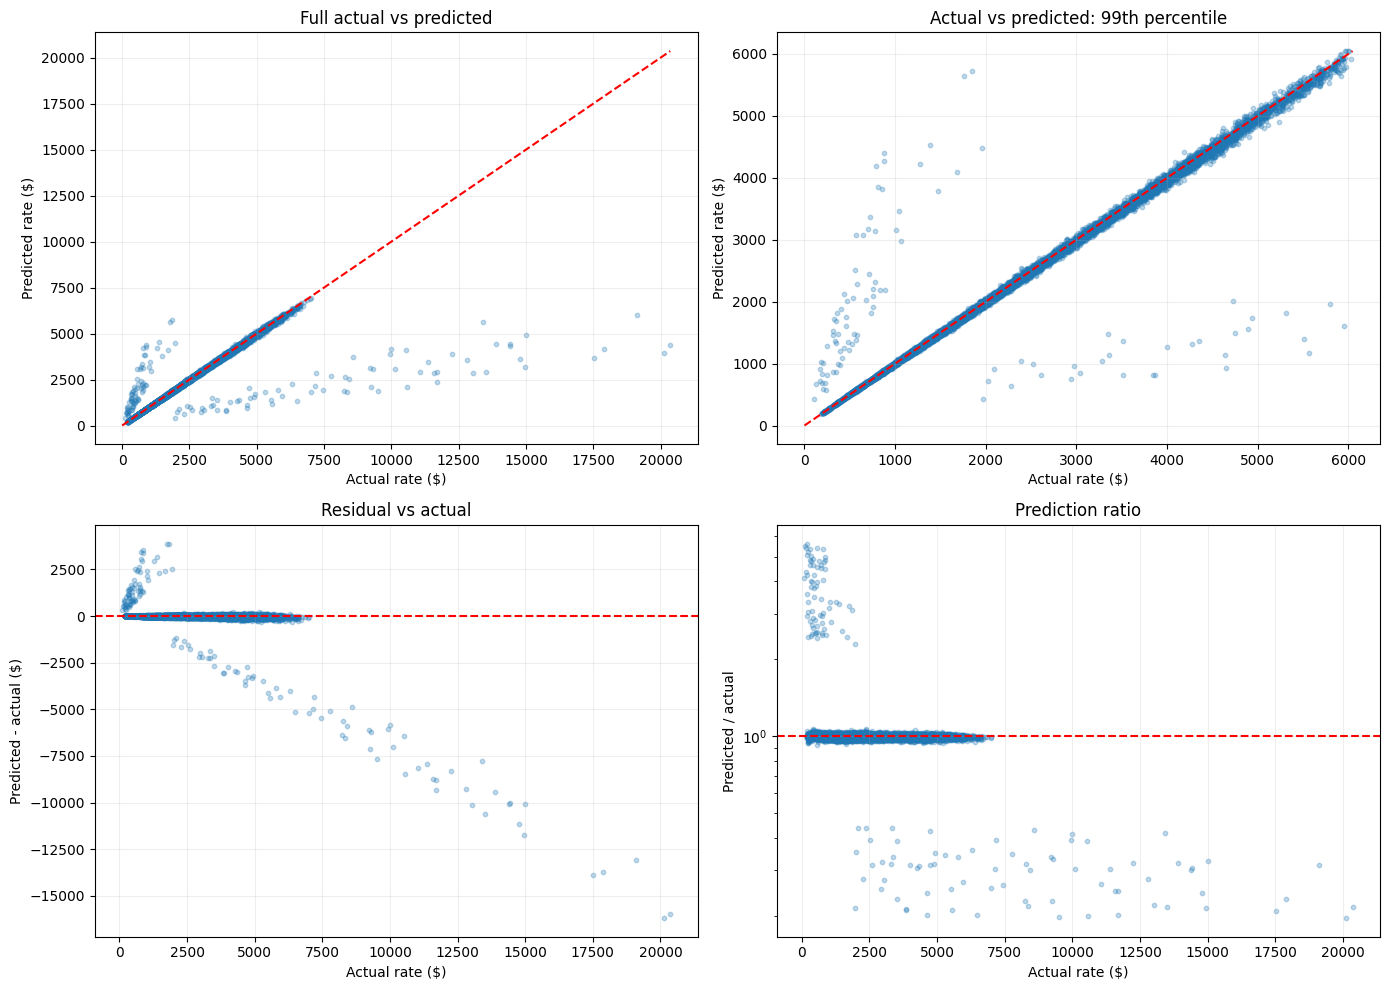

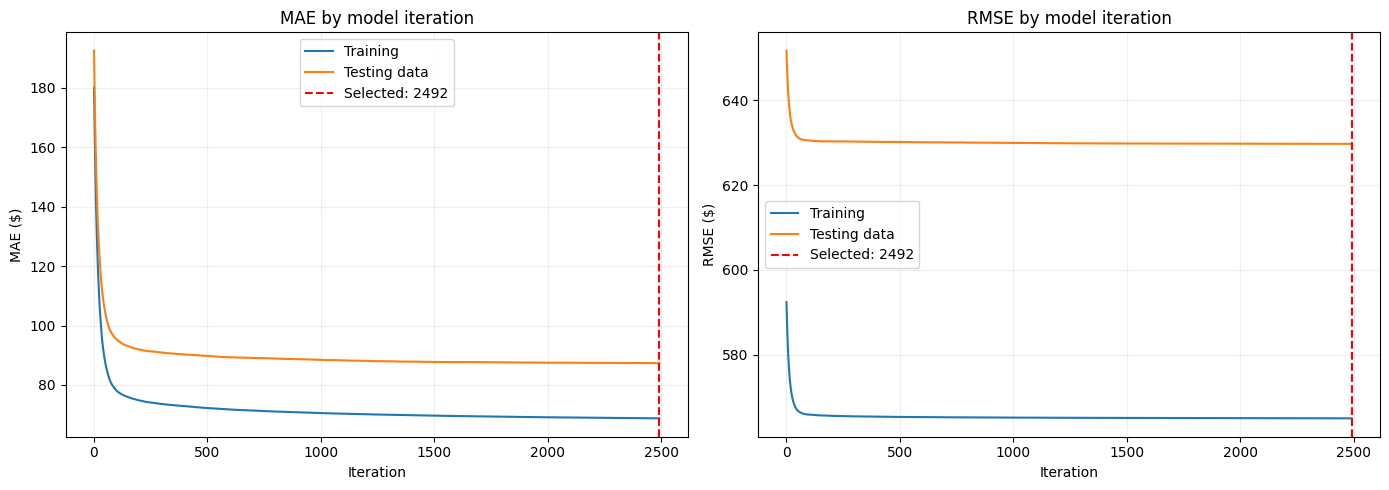

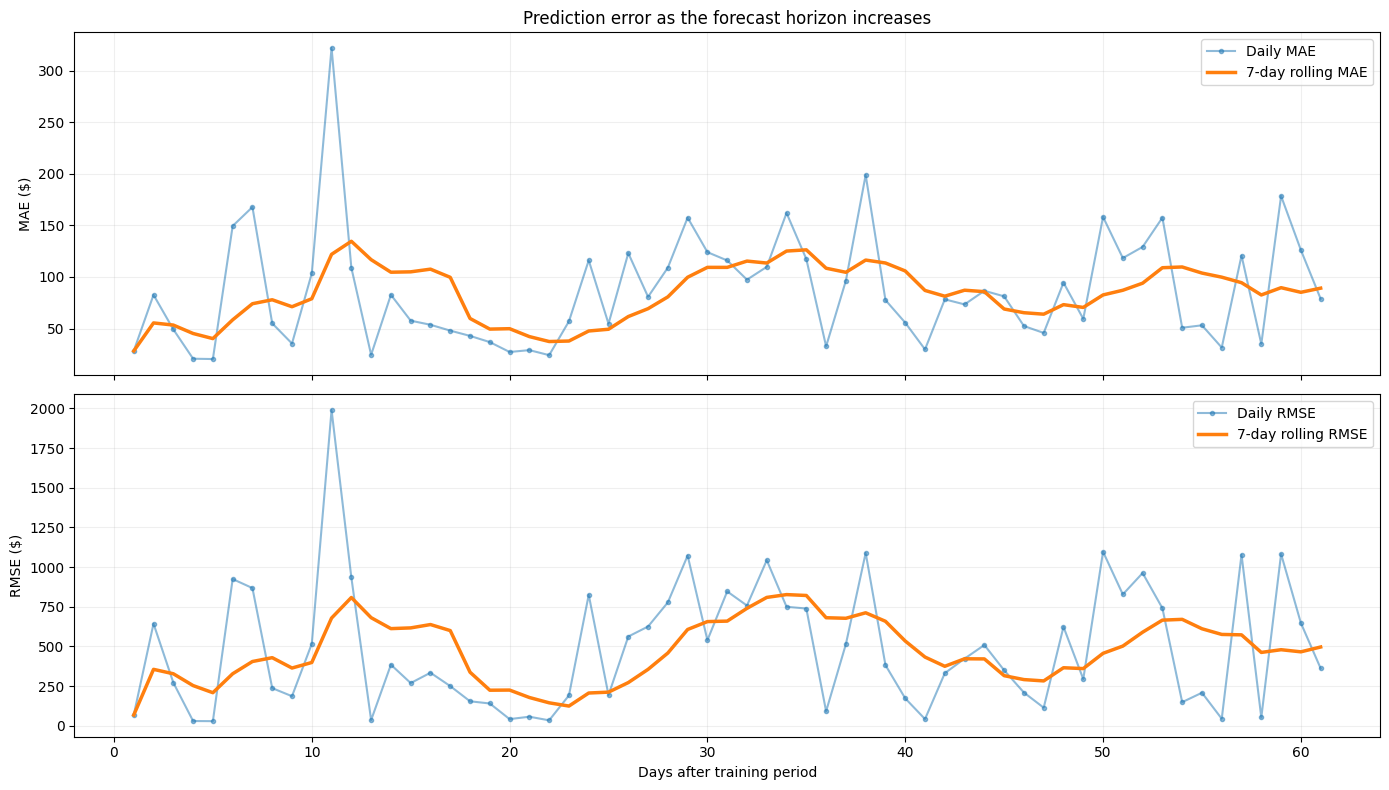

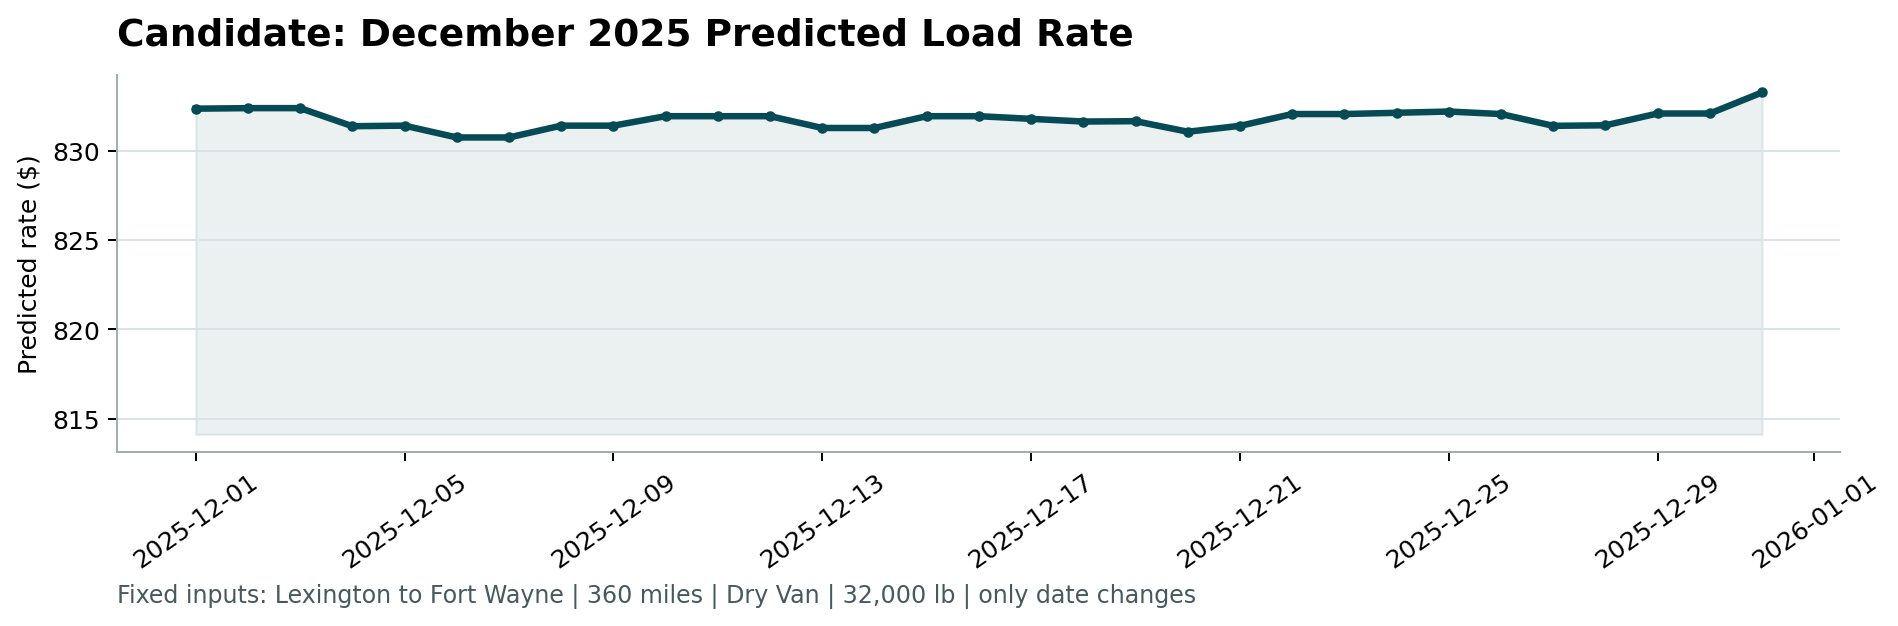

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# model analysis

# monthly metrics

testing_dates = pd.to_datetime(testing_evaluation['date'], errors='raise')
testing_periods = sorted(testing_dates.dt.to_period('M').unique())
if len(testing_periods) != 2:
    raise ValueError(f'Expected two testing months; found {len(testing_periods)}')

def metrics_for_period(period=None):
    if period is None:
        rows = testing_evaluation
    else:
        rows = testing_evaluation.loc[testing_dates.dt.to_period('M') == period]
    return calculate_metrics(rows['actual_rate'], rows['predicted_rate'])
first_metrics = metrics_for_period(testing_periods[0])
second_metrics = metrics_for_period(testing_periods[1])
combined_metrics = metrics_for_period()
training_metrics = calculate_metrics(training_evaluation['actual_rate'], training_evaluation['predicted_rate'])
first_label = f"{testing_periods[0].strftime('%B %Y')} testing data"
second_label = f"{testing_periods[1].strftime('%B %Y')} testing data"
metrics_table = pd.DataFrame({'Metric': list(combined_metrics), 'Training data': [training_metrics[name] for name in combined_metrics], first_label: [first_metrics[name] for name in combined_metrics], second_label: [second_metrics[name] for name in combined_metrics], 'Combined testing data': list(combined_metrics.values())})

# missing signal test

def predict_with_hidden_signals(source_rows, hidden_columns):
    prediction_rows = source_rows.copy()
    for column_name in hidden_columns:
        prediction_rows[column_name] = np.nan
    prediction_rows = fill_missing_market_signals(
        prediction_rows,
        raw_train_rows,
        columns=hidden_columns,
    )
    prediction_features = build_features(
        prediction_rows,
        coordinate_reference=INTERNAL_CITY_COORDINATE_REFERENCE,
    )
    prediction_processed = as_dense(
        selected_preprocessor.transform(prediction_features)
    )
    return inverse_target(
        trained_model.predict(prediction_processed),
        source_rows,
    )

def scenario_mae_row(scenario, train_predictions, test_predictions):
    test_dates = pd.to_datetime(raw_test_rows['date'], errors='raise')
    first_mask = test_dates.dt.to_period('M') == testing_periods[0]
    second_mask = test_dates.dt.to_period('M') == testing_periods[1]
    return {
        'Input scenario': scenario,
        'Training MAE ($)': mean_absolute_error(y_train_actual, train_predictions),
        f'{testing_periods[0].strftime("%B %Y")} MAE ($)': mean_absolute_error(y_test_actual[first_mask], test_predictions[first_mask]),
        f'{testing_periods[1].strftime("%B %Y")} MAE ($)': mean_absolute_error(y_test_actual[second_mask], test_predictions[second_mask]),
        'Combined testing MAE ($)': mean_absolute_error(y_test_actual, test_predictions),
    }

missing_both_train_predictions = predict_with_hidden_signals(
    raw_train_rows,
    ['market_index', 'quote_signal'],
)
missing_both_test_predictions = predict_with_hidden_signals(
    raw_test_rows,
    ['market_index', 'quote_signal'],
)
quote_baseline_train_rows = fill_missing_market_signals(
    raw_train_rows,
    raw_train_rows,
    columns=['quote_signal'],
)
quote_baseline_test_rows = fill_missing_market_signals(
    raw_test_rows,
    raw_train_rows,
    columns=['quote_signal'],
)
quote_baseline_train_predictions = (
    quote_baseline_train_rows['quote_signal'].to_numpy(dtype=float)
    * raw_train_rows['distance'].to_numpy(dtype=float)
)
quote_baseline_test_predictions = (
    quote_baseline_test_rows['quote_signal'].to_numpy(dtype=float)
    * raw_test_rows['distance'].to_numpy(dtype=float)
)
signal_test_table = pd.DataFrame(
    [
        scenario_mae_row(
            'Full selected model',
            train_rate_predictions,
            test_rate_predictions,
        ),
        scenario_mae_row(
            'Selected model with market_index and quote_signal hidden and training medians supplied',
            missing_both_train_predictions,
            missing_both_test_predictions,
        ),
        scenario_mae_row(
            'quote_signal multiplied by distance baseline',
            quote_baseline_train_predictions,
            quote_baseline_test_predictions,
        ),
    ]
)

# diagnostic plots

def build_daily_error_results(evaluation, training_end_date):
    work = evaluation.copy()
    work['date'] = pd.to_datetime(work['date'], errors='raise')
    training_end_date = pd.Timestamp(training_end_date)
    work['squared_error'] = work['residual'] ** 2
    result = work.groupby('date', as_index=False).agg(rows=('actual_rate', 'size'), mae=('absolute_error', 'mean'), mean_squared_error=('squared_error', 'mean'))
    result['rmse'] = np.sqrt(result.pop('mean_squared_error'))
    result['days_after_training'] = (result['date'] - training_end_date).dt.days
    result['rolling_7_day_mae'] = result['mae'].rolling(7, min_periods=1).mean()
    result['rolling_7_day_rmse'] = result['rmse'].rolling(7, min_periods=1).mean()
    return result
daily_error_results = build_daily_error_results(testing_evaluation, pd.to_datetime(raw_train_rows['date'], errors='raise').max())

def create_prediction_diagnostics(evaluation):
    figure, axes = plt.subplots(2, 2, figsize=(14, 10))
    actual = evaluation['actual_rate'].to_numpy()
    predicted = evaluation['predicted_rate'].to_numpy()
    residual = evaluation['residual'].to_numpy()
    ratio = evaluation['prediction_ratio'].to_numpy()
    full_limit = max(actual.max(), predicted.max())
    axes[0, 0].scatter(actual, predicted, alpha=0.28, s=10)
    axes[0, 0].plot([0, full_limit], [0, full_limit], 'r--')
    axes[0, 0].set(title='Full actual vs predicted', xlabel='Actual rate ($)', ylabel='Predicted rate ($)')
    percentile_limit = np.quantile(actual, 0.99)
    mask = actual <= percentile_limit
    display_limit = max(actual[mask].max(), predicted[mask].max())
    axes[0, 1].scatter(actual[mask], predicted[mask], alpha=0.28, s=10)
    axes[0, 1].plot([0, display_limit], [0, display_limit], 'r--')
    axes[0, 1].set(title='Actual vs predicted: 99th percentile', xlabel='Actual rate ($)', ylabel='Predicted rate ($)')
    axes[1, 0].scatter(actual, residual, alpha=0.28, s=10)
    axes[1, 0].axhline(0, color='red', linestyle='--')
    axes[1, 0].set(title='Residual vs actual', xlabel='Actual rate ($)', ylabel='Predicted - actual ($)')
    axes[1, 1].scatter(actual, np.maximum(ratio, 0.0001), alpha=0.28, s=10)
    axes[1, 1].axhline(1, color='red', linestyle='--')
    axes[1, 1].set_yscale('log')
    axes[1, 1].set(title='Prediction ratio', xlabel='Actual rate ($)', ylabel='Predicted / actual')
    for axis in axes.flat:
        axis.grid(alpha=0.2)
    figure.tight_layout()
    return figure

def create_iteration_diagnostics(history):
    figure, axes = plt.subplots(1, 2, figsize=(14, 5))
    selected = int(history.loc[history['Selected'], 'Iteration'].iloc[0])
    axes[0].plot(history['Iteration'], history['Train MAE ($)'], label='Training')
    axes[0].plot(history['Iteration'], history['Holdout MAE ($)'], label='Testing data')
    axes[0].axvline(selected, color='red', linestyle='--', label=f'Selected: {selected}')
    axes[0].set(title='MAE by model iteration', xlabel='Iteration', ylabel='MAE ($)')
    axes[1].plot(history['Iteration'], history['Train RMSE ($)'], label='Training')
    axes[1].plot(history['Iteration'], history['Holdout RMSE ($)'], label='Testing data')
    axes[1].axvline(selected, color='red', linestyle='--', label=f'Selected: {selected}')
    axes[1].set(title='RMSE by model iteration', xlabel='Iteration', ylabel='RMSE ($)')
    for axis in axes:
        axis.legend()
        axis.grid(alpha=0.2)
    figure.tight_layout()
    return figure

def create_daily_error_diagnostics(results):
    figure, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    x = results['days_after_training']
    axes[0].plot(x, results['mae'], marker='o', markersize=3, alpha=0.5, label='Daily MAE')
    axes[0].plot(x, results['rolling_7_day_mae'], linewidth=2.5, label='7-day rolling MAE')
    axes[0].set(title='Prediction error as the forecast horizon increases', ylabel='MAE ($)')
    axes[1].plot(x, results['rmse'], marker='o', markersize=3, alpha=0.5, label='Daily RMSE')
    axes[1].plot(x, results['rolling_7_day_rmse'], linewidth=2.5, label='7-day rolling RMSE')
    axes[1].set(xlabel='Days after training period', ylabel='RMSE ($)')
    for axis in axes:
        axis.legend()
        axis.grid(alpha=0.2)
    figure.tight_layout()
    return figure
prediction_figure = create_prediction_diagnostics(testing_evaluation)
iteration_figure = create_iteration_diagnostics(iteration_history)
daily_figure = create_daily_error_diagnostics(daily_error_results)
prediction_plot_path = DATA_DIR / 'prediction_diagnostics.png'
iteration_plot_path = DATA_DIR / 'iteration_diagnostics.png'
daily_plot_path = DATA_DIR / 'forecast_horizon_diagnostics.png'
prediction_figure.savefig(prediction_plot_path, dpi=150, bbox_inches='tight')
iteration_figure.savefig(iteration_plot_path, dpi=150, bbox_inches='tight')
daily_figure.savefig(daily_plot_path, dpi=150, bbox_inches='tight')
display(metrics_table.round(3))
display(signal_test_table.round(3))
display(prediction_figure)
display(iteration_figure)
display(daily_figure)
plt.close(prediction_figure)
plt.close(iteration_figure)
plt.close(daily_figure)


# final model and validation predictions

required_interface = ['PREPROCESSING_NAME', 'MODEL_NAME', 'build_features', 'create_preprocessor', 'transform_target', 'inverse_target', 'create_model', 'metrics_table', 'signal_test_table']
missing_interface = [name for name in required_interface if name not in globals()]
if missing_interface:
    raise RuntimeError(f'Run cells 1 through 3 first. Missing: {missing_interface}')
# final fitting

final_train_features = build_features(train_df)
final_validation_rows = fill_missing_market_signals(validation_df, train_df)
final_december_rows = fill_missing_market_signals(december_df, train_df)
final_validation_features = build_features(final_validation_rows)
final_december_features = build_features(final_december_rows)
final_preprocessor = create_preprocessor()
final_train_processed = as_dense(final_preprocessor.fit_transform(final_train_features))
final_validation_processed = as_dense(final_preprocessor.transform(final_validation_features))
final_december_processed = as_dense(final_preprocessor.transform(final_december_features))
final_target = transform_target(train_df)
final_model = create_model()
final_model.fit(final_train_processed, final_target)
# validation predictions

validation_rate_predictions = inverse_target(final_model.predict(final_validation_processed), validation_df)
validation_rate_predictions = np.round(np.maximum(validation_rate_predictions, 0.01), 2)
prediction_by_id = pd.Series(validation_rate_predictions, index=validation_df['load_id'].astype(str).to_numpy())
submission_df = template_df[['load_id']].copy()
submission_df['predicted_rate'] = submission_df['load_id'].astype(str).map(prediction_by_id)
assert list(submission_df.columns) == ['load_id', 'predicted_rate']
assert len(submission_df) == 12000
assert submission_df['load_id'].is_unique
assert submission_df['predicted_rate'].notna().all()
assert np.isfinite(submission_df['predicted_rate']).all()
assert (submission_df['predicted_rate'] > 0).all()
assert set(submission_df['load_id'].astype(str)) == set(validation_df['load_id'].astype(str))
validation_output_path = DATA_DIR / 'validation_predictions.csv'
submission_df.to_csv(validation_output_path, index=False)
# december predictions and scorer

december_rate_predictions = inverse_target(final_model.predict(final_december_processed), december_df)
december_rate_predictions = np.round(np.maximum(december_rate_predictions, 0.01), 2)
required_december_columns = ['pickup', 'delivery', 'distance', 'equipment', 'weight', 'date', 'predicted_rate']
december_output_df = december_df[[name for name in required_december_columns if name != 'predicted_rate']].copy()
december_output_df['predicted_rate'] = december_rate_predictions
assert list(december_output_df.columns) == required_december_columns
assert len(december_output_df) == 31
assert december_output_df['date'].is_unique
assert december_output_df['predicted_rate'].notna().all()
december_output_path = DATA_DIR / 'december_predictions.csv'
december_output_df.to_csv(december_output_path, index=False)
scorer_output_dir = DATA_DIR / 'scorer_results'
score_process = subprocess.run([sys.executable, str(DATA_DIR / 'score.py'), '--predictions', str(validation_output_path), '--december-predictions', str(december_output_path), '--output-dir', str(scorer_output_dir)], text=True, capture_output=True)
if score_process.returncode != 0:
    raise RuntimeError(score_process.stdout + '\n' + score_process.stderr)
chart_path = scorer_output_dir / 'candidate_december.png'
assert chart_path.exists()
display(Image(filename=str(chart_path)))
# required downloads

december_archive_path = DATA_DIR / 'december_outputs.zip'
with zipfile.ZipFile(december_archive_path, 'w', zipfile.ZIP_DEFLATED) as archive:
    archive.write(december_output_path, december_output_path.name)
    archive.write(chart_path, chart_path.name)

try:
    from google.colab import files
    files.download(str(validation_output_path))
    files.download(str(december_archive_path))
except ImportError:
    pass
